# Masked Autoencoder (MAE) for Self-Supervised Image Representation Learning

This notebook implements a Masked Autoencoder (MAE) based on the paper *"Masked Autoencoders Are Scalable Vision Learners"* (He et al., 2022). The model is trained on TinyImageNet for self-supervised representation learning.

**Key Idea:** Randomly mask 75% of image patches, encode only the visible 25%, then reconstruct the masked patches using a lightweight decoder.

## 1. Imports

In [1]:
import os
import math
import random
import glob
import json
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    # print(f'VRAM: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB')

cuda
Using device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
class Config:
    # Dataset
    data_dir = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
    image_size = 224
    
    # Patch embedding
    patch_size = 16
    num_patches = (image_size // patch_size) ** 2  # 196
    
    # Masking
    mask_ratio = 0.75
    
    # Encoder (ViT-Base)
    enc_dim = 768
    enc_layers = 12
    enc_heads = 12
    
    # Decoder (ViT-Small)
    dec_dim = 384
    dec_layers = 12
    dec_heads = 6
    
    # Training
    batch_size = 32
    epochs = 10
    lr = 1.5e-4
    weight_decay = 0.05
    betas = (0.9, 0.95)
    warmup_epochs = 5
    grad_clip = 1.0
    
    # Checkpointing
    save_every = 10
    checkpoint_dir = './checkpoints'
    
    # Workers
    num_workers = 2

cfg = Config()
os.makedirs(cfg.checkpoint_dir, exist_ok=True)
print(f'Number of patches: {cfg.num_patches}')
print(f'Visible patches: {int(cfg.num_patches * (1 - cfg.mask_ratio))}')
print(f'Masked patches: {int(cfg.num_patches * cfg.mask_ratio)}')

Number of patches: 196
Visible patches: 49
Masked patches: 147


## 3. Dataset & DataLoaders

In [3]:
class TinyImageNetDataset(Dataset):
    """TinyImageNet dataset for self-supervised learning (no labels needed)."""
    
    def __init__(self, root_dir, split='train', transform=None):
        self.transform = transform
        self.image_paths = []
        
        if split == 'train':
            # train/{class}/images/*.JPEG
            train_dir = os.path.join(root_dir, 'train')
            for class_dir in os.listdir(train_dir):
                img_dir = os.path.join(train_dir, class_dir, 'images')
                if os.path.isdir(img_dir):
                    for img_name in os.listdir(img_dir):
                        if img_name.endswith('.JPEG'):
                            self.image_paths.append(os.path.join(img_dir, img_name))
        elif split == 'val':
            # val/images/*.JPEG
            val_img_dir = os.path.join(root_dir, 'val', 'images')
            if os.path.isdir(val_img_dir):
                for img_name in os.listdir(val_img_dir):
                    if img_name.endswith('.JPEG'):
                        self.image_paths.append(os.path.join(val_img_dir, img_name))
        
        print(f'{split} set: {len(self.image_paths)} images')
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets and dataloaders
train_dataset = TinyImageNetDataset(cfg.data_dir, split='train', transform=train_transform)
val_dataset = TinyImageNetDataset(cfg.data_dir, split='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers, pin_memory=True)

train set: 100000 images
val set: 10000 images


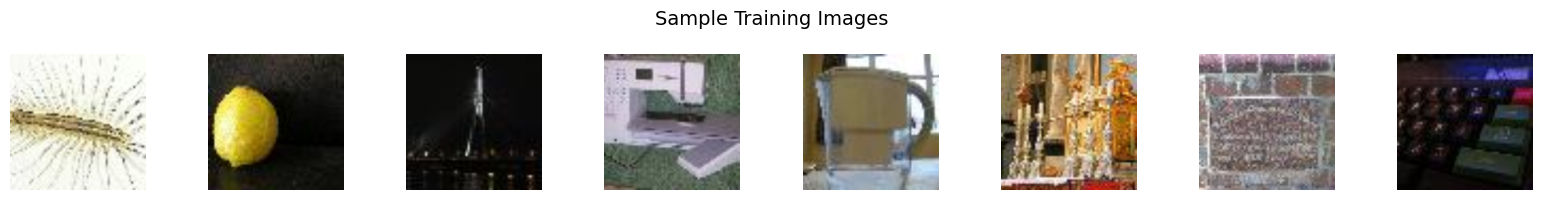

In [4]:
# Visualize sample images
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Reverse ImageNet normalization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

sample_batch = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = denormalize(sample_batch[i])
    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].axis('off')
fig.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Model Components

In [5]:
class PatchEmbedding(nn.Module):
    """Convert image into patch embeddings using a convolution."""
    
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: (B, C, H, W) -> (B, num_patches, embed_dim)
        x = self.proj(x)           # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention mechanism."""
    
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # each: (B, heads, N, head_dim)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x


class MLP(nn.Module):
    """Feed-forward network with GELU activation."""
    
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
    
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class TransformerBlock(nn.Module):
    """Standard Vision Transformer block: LN -> MHSA -> LN -> MLP."""
    
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

print('Model components defined: PatchEmbedding, MultiHeadSelfAttention, MLP, TransformerBlock')

Model components defined: PatchEmbedding, MultiHeadSelfAttention, MLP, TransformerBlock


## 5. MAE Model

In [6]:
class MAE(nn.Module):
    """Masked Autoencoder with ViT encoder and decoder."""
    
    def __init__(self, image_size=224, patch_size=16, in_channels=3,
                 enc_dim=768, enc_layers=12, enc_heads=12,
                 dec_dim=384, dec_layers=12, dec_heads=6,
                 mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size  # 3*16*16 = 768
        
        # ---------- Encoder ----------
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, enc_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, enc_dim))
        # +1 for CLS token
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, enc_dim))
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(enc_dim, enc_heads) for _ in range(enc_layers)
        ])
        self.encoder_norm = nn.LayerNorm(enc_dim)
        
        # ---------- Decoder ----------
        self.decoder_embed = nn.Linear(enc_dim, dec_dim)  # project encoder output
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, dec_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(dec_dim, dec_heads) for _ in range(dec_layers)
        ])
        self.decoder_norm = nn.LayerNorm(dec_dim)
        self.decoder_pred = nn.Linear(dec_dim, self.patch_dim)  # predict pixel values
        
        self._init_weights()
    
    def _init_weights(self):
        # Initialize position embeddings with sin-cos (approximate with normal)
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.decoder_pos_embed, std=0.02)
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Initialize all linear and conv layers
        self.apply(self._init_module_weights)
    
    def _init_module_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
    
    def patchify(self, imgs):
        """Convert images to patch sequences.
        imgs: (B, 3, H, W) -> patches: (B, num_patches, patch_dim)
        """
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        patches = imgs.reshape(B, C, h, p, w, p)
        patches = patches.permute(0, 2, 4, 3, 5, 1)  # (B, h, w, p, p, C)
        patches = patches.reshape(B, h * w, p * p * C)  # (B, num_patches, patch_dim)
        return patches
    
    def unpatchify(self, patches):
        """Convert patch sequences back to images.
        patches: (B, num_patches, patch_dim) -> imgs: (B, 3, H, W)
        """
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        C = 3
        patches = patches.reshape(-1, h, w, p, p, C)
        imgs = patches.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, p, w, p)
        imgs = imgs.reshape(-1, C, h * p, w * p)
        return imgs
    
    def random_masking(self, x, mask_ratio):
        """Random masking: keep (1-mask_ratio) patches, remove the rest.
        
        Args:
            x: (B, N, D) patch embeddings (without CLS)
            mask_ratio: fraction of patches to mask
        
        Returns:
            x_visible: (B, N_visible, D) visible patch embeddings
            mask: (B, N) binary mask, 1=masked, 0=visible
            ids_restore: (B, N) indices to restore original order
        """
        B, N, D = x.shape
        num_keep = int(N * (1 - mask_ratio))
        
        # Random noise for shuffling
        noise = torch.rand(B, N, device=x.device)
        
        # Sort noise to get shuffle indices
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        # Keep the first num_keep tokens (smallest noise values)
        ids_keep = ids_shuffle[:, :num_keep]
        x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
        
        # Generate binary mask: 0=visible, 1=masked
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_visible, mask, ids_restore
    
    def encode(self, x, mask_ratio):
        """Encode visible patches only."""
        # Patch embedding
        x = self.patch_embed(x)  # (B, N, enc_dim)
        
        # Add positional embeddings (without CLS position)
        x = x + self.pos_embed[:, 1:, :]
        
        # Random masking
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        
        # Prepend CLS token
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 1+N_visible, enc_dim)
        
        # Apply transformer blocks
        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)
        
        return x, mask, ids_restore
    
    def decode(self, x, ids_restore):
        """Decode all patches (visible + masked)."""
        # Project encoder output to decoder dimension
        x = self.decoder_embed(x)  # (B, 1+N_visible, dec_dim)
        
        # Append mask tokens for masked positions
        num_masked = self.num_patches + 1 - x.shape[1]  # +1 for CLS
        mask_tokens = self.mask_token.repeat(x.shape[0], num_masked, 1)
        
        # Concatenate visible tokens (without CLS) and mask tokens
        x_no_cls = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # (B, N, dec_dim)
        
        # Unshuffle to restore original order
        x_no_cls = torch.gather(
            x_no_cls, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, x_no_cls.shape[2])
        )
        
        # Prepend CLS token back
        x = torch.cat([x[:, :1, :], x_no_cls], dim=1)  # (B, 1+N, dec_dim)
        
        # Add decoder positional embeddings
        x = x + self.decoder_pos_embed
        
        # Apply transformer blocks
        for block in self.decoder_blocks:
            x = block(x)
        x = self.decoder_norm(x)
        
        # Predict pixel values (remove CLS token)
        x = self.decoder_pred(x[:, 1:, :])  # (B, N, patch_dim)
        
        return x
    
    def forward(self, imgs, mask_ratio=None):
        """Full forward pass: encode visible, decode all, compute loss."""
        if mask_ratio is None:
            mask_ratio = self.mask_ratio
        
        # Encode
        latent, mask, ids_restore = self.encode(imgs, mask_ratio)
        
        # Decode
        pred = self.decode(latent, ids_restore)  # (B, N, patch_dim)
        
        # Compute loss
        target = self.patchify(imgs)  # (B, N, patch_dim)
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # per-patch MSE: (B, N)
        
        # Only compute loss on masked patches
        loss = (loss * mask).sum() / mask.sum()
        
        return loss, pred, mask

print('MAE model defined.')

MAE model defined.


## 6. Model Summary

In [7]:
model = MAE(
    image_size=cfg.image_size,
    patch_size=cfg.patch_size,
    enc_dim=cfg.enc_dim,
    enc_layers=cfg.enc_layers,
    enc_heads=cfg.enc_heads,
    dec_dim=cfg.dec_dim,
    dec_layers=cfg.dec_layers,
    dec_heads=cfg.dec_heads,
    mask_ratio=cfg.mask_ratio,
).to(device)

# Count parameters
def count_params(module):
    return sum(p.numel() for p in module.parameters())

enc_params = (
    count_params(model.patch_embed) +
    model.cls_token.numel() +
    model.pos_embed.numel() +
    count_params(model.encoder_blocks) +
    count_params(model.encoder_norm)
)

dec_params = (
    count_params(model.decoder_embed) +
    model.mask_token.numel() +
    model.decoder_pos_embed.numel() +
    count_params(model.decoder_blocks) +
    count_params(model.decoder_norm) +
    count_params(model.decoder_pred)
)

total_params = count_params(model)

print(f'Encoder parameters: {enc_params / 1e6:.2f}M')
print(f'Decoder parameters: {dec_params / 1e6:.2f}M')
print(f'Total parameters:   {total_params / 1e6:.2f}M')
print()

# Quick forward pass test
with torch.no_grad():
    dummy = torch.randn(2, 3, cfg.image_size, cfg.image_size).to(device)
    loss, pred, mask = model(dummy)
    print(f'Test forward pass:')
    print(f'  Input shape:  {dummy.shape}')
    print(f'  Output shape: {pred.shape}')
    print(f'  Mask shape:   {mask.shape}')
    print(f'  Loss:         {loss.item():.4f}')

Encoder parameters: 85.80M
Decoder parameters: 21.96M
Total parameters:   107.76M

Test forward pass:
  Input shape:  torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 196, 768])
  Mask shape:   torch.Size([2, 196])
  Loss:         1.6398


## 7. Training Loop

In [8]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    betas=cfg.betas
)

# Cosine LR scheduler with linear warmup
def get_lr(epoch, warmup_epochs, total_epochs, base_lr):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

# Mixed precision scaler
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# Training history
train_losses = []
val_losses = []

print(f'Starting training for {cfg.epochs} epochs...')
print(f'Batch size: {cfg.batch_size}, LR: {cfg.lr}')
print(f'Training batches per epoch: {len(train_loader)}')
print()

Starting training for 10 epochs...
Batch size: 32, LR: 0.00015
Training batches per epoch: 3125



In [9]:
for epoch in range(cfg.epochs):
    # ---- Update learning rate ----
    lr = get_lr(epoch, cfg.warmup_epochs, cfg.epochs, cfg.lr)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    # ---- Train ----
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{cfg.epochs}', leave=True)
    
    for batch_idx, imgs in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss, _, _ = model(imgs)
        
        scaler.scale(loss).backward()
        
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{lr:.6f}'})
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                loss, _, _ = model(imgs)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f'Epoch {epoch+1}/{cfg.epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {lr:.6f}')
    
    # ---- Save checkpoint ----
    if (epoch + 1) % cfg.save_every == 0:
        ckpt_path = os.path.join(cfg.checkpoint_dir, f'mae_epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, ckpt_path)
        print(f'  -> Checkpoint saved: {ckpt_path}')

print('\nTraining complete!')

Epoch 1/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.9298 | Val Loss: 0.8608 | LR: 0.000030


Epoch 2/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 2/10 | Train Loss: 0.7785 | Val Loss: 0.7287 | LR: 0.000060


Epoch 3/10:   0%|          | 0/3125 [00:00<?, ?it/s]

...

Epoch 8/10 | Train Loss: 0.2750 | Val Loss: 0.2717 | LR: 0.000098


Epoch 9/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.2623 | Val Loss: 0.2597 | LR: 0.000052


Epoch 10/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2545 | Val Loss: 0.2528 | LR: 0.000014
  -> Checkpoint saved: ./checkpoints/mae_epoch_10.pt

Training complete!


## 8. Loss Plot

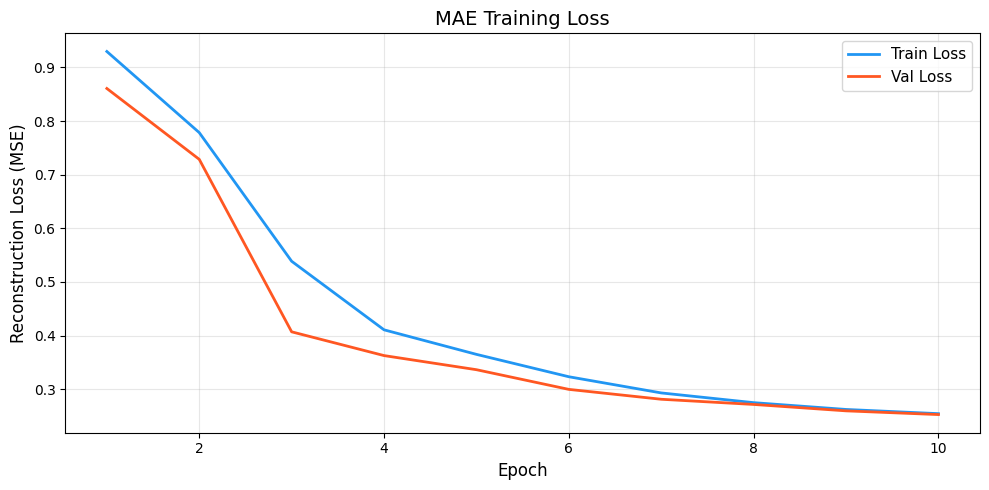

Final Train Loss: 0.2545
Final Val Loss:   0.2528


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
epochs_range = range(1, len(train_losses) + 1)

ax.plot(epochs_range, train_losses, label='Train Loss', color='#2196F3', linewidth=2)
ax.plot(epochs_range, val_losses, label='Val Loss', color='#FF5722', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Reconstruction Loss (MSE)', fontsize=12)
ax.set_title('MAE Training Loss', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final Train Loss: {train_losses[-1]:.4f}')
print(f'Final Val Loss:   {val_losses[-1]:.4f}')

## 9. Reconstruction Visualization

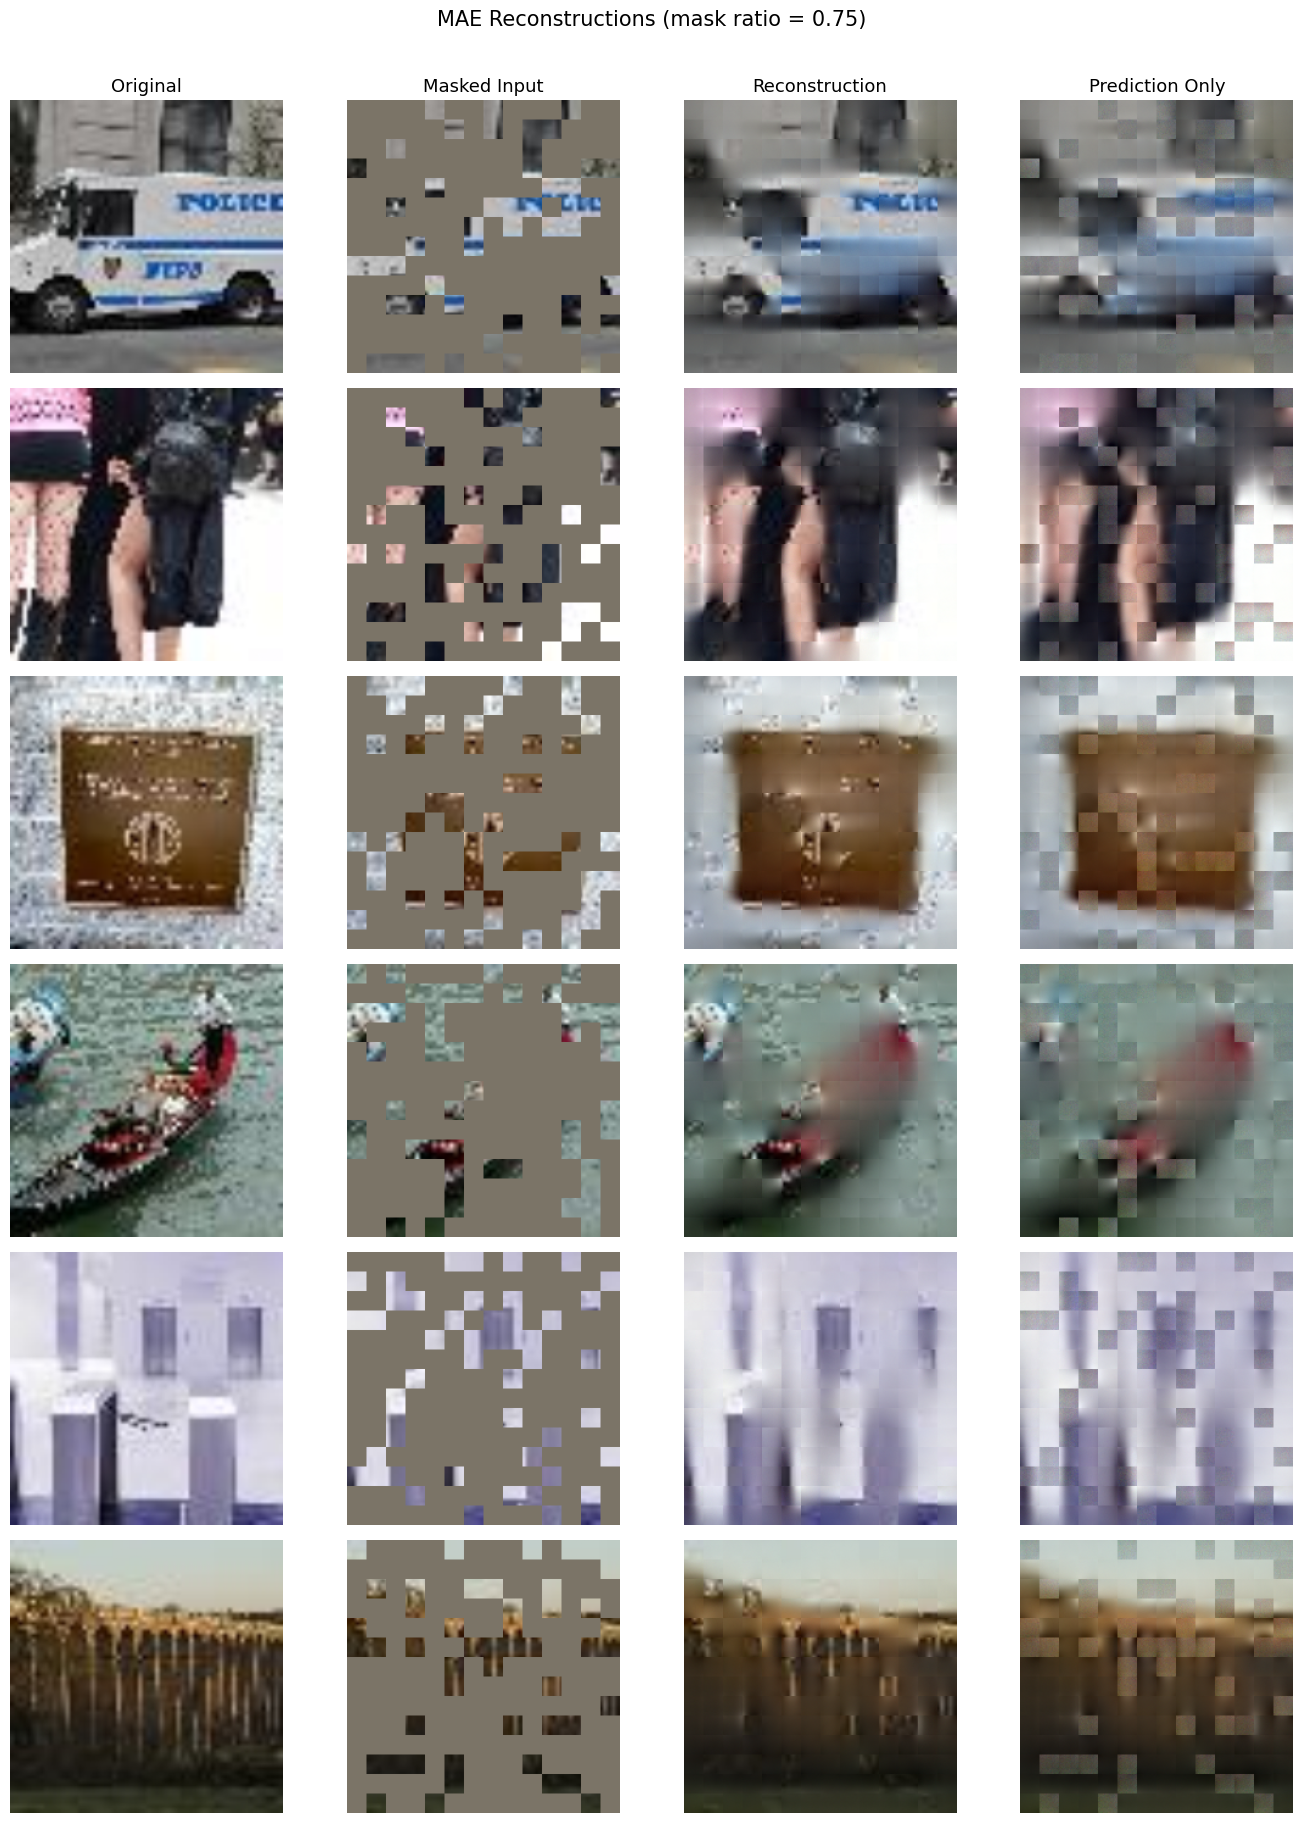

In [11]:
def visualize_reconstructions(model, dataloader, num_images=6, mask_ratio=0.75):
    """Visualize: Original | Masked Input | Reconstruction | Reconstruction (visible+pred)"""
    model.eval()
    imgs = next(iter(dataloader))[:num_images].to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss, pred, mask = model(imgs, mask_ratio=mask_ratio)
    
    # pred: (B, N, patch_dim), mask: (B, N)
    target = model.patchify(imgs)  # (B, N, patch_dim)
    
    # Build full reconstruction: visible patches from original, masked patches from prediction
    mask_expanded = mask.unsqueeze(-1).expand_as(target)  # (B, N, patch_dim)
    full_recon = target * (1 - mask_expanded) + pred * mask_expanded
    
    # Build masked input: visible patches from original, masked patches set to gray
    gray_value = 0.0  # in normalized space
    masked_input = target * (1 - mask_expanded) + gray_value * mask_expanded
    
    # Unpatchify
    recon_imgs = model.unpatchify(full_recon).cpu()
    masked_imgs = model.unpatchify(masked_input).cpu()
    pred_only_imgs = model.unpatchify(pred).cpu()
    orig_imgs = imgs.cpu()
    
    # Plot
    fig, axes = plt.subplots(num_images, 4, figsize=(14, 3 * num_images))
    titles = ['Original', 'Masked Input', 'Reconstruction', 'Prediction Only']
    
    for i in range(num_images):
        images = [
            denormalize(orig_imgs[i]),
            denormalize(masked_imgs[i]),
            denormalize(recon_imgs[i]),
            denormalize(pred_only_imgs[i]),
        ]
        for j, img in enumerate(images):
            axes[i, j].imshow(img.permute(1, 2, 0).numpy())
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(titles[j], fontsize=13)
    
    fig.suptitle(f'MAE Reconstructions (mask ratio = {mask_ratio})', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_reconstructions(model, val_loader, num_images=6)

## 10. Quantitative Metrics (PSNR & SSIM)

In [12]:
def compute_psnr(img1, img2, max_val=1.0):
    """Compute Peak Signal-to-Noise Ratio between two images."""
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return float('inf')
    return 10 * math.log10(max_val ** 2 / mse)


def gaussian_kernel(size=11, sigma=1.5, channels=3):
    """Create a Gaussian kernel for SSIM computation."""
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = torch.outer(g, g)
    g = g / g.sum()
    kernel = g.unsqueeze(0).unsqueeze(0).repeat(channels, 1, 1, 1)
    return kernel


def compute_ssim(img1, img2, window_size=11, C1=0.01**2, C2=0.03**2):
    """Compute Structural Similarity Index between two image batches."""
    channels = img1.shape[1]
    kernel = gaussian_kernel(window_size, 1.5, channels).to(img1.device)
    padding = window_size // 2
    
    mu1 = F.conv2d(img1, kernel, padding=padding, groups=channels)
    mu2 = F.conv2d(img2, kernel, padding=padding, groups=channels)
    
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2
    
    sigma1_sq = F.conv2d(img1 * img1, kernel, padding=padding, groups=channels) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, kernel, padding=padding, groups=channels) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, kernel, padding=padding, groups=channels) - mu1_mu2
    
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    
    return ssim_map.mean().item()


# Evaluate on validation set
model.eval()
psnr_scores = []
ssim_scores = []
num_eval_batches = 20  # Evaluate on subset for speed

print('Computing PSNR and SSIM on validation set...')
with torch.no_grad():
    for batch_idx, imgs in enumerate(tqdm(val_loader, total=min(num_eval_batches, len(val_loader)))):
        if batch_idx >= num_eval_batches:
            break
        
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss, pred, mask = model(imgs)
        
        # Build full reconstruction
        target = model.patchify(imgs)
        mask_expanded = mask.unsqueeze(-1).expand_as(target)
        full_recon = target * (1 - mask_expanded) + pred.float() * mask_expanded
        
        # Unpatchify and denormalize
        recon = model.unpatchify(full_recon)
        
        # Denormalize for metric computation
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
        orig_denorm = (imgs * std + mean).clamp(0, 1)
        recon_denorm = (recon * std + mean).clamp(0, 1)
        
        psnr_scores.append(compute_psnr(recon_denorm, orig_denorm))
        ssim_scores.append(compute_ssim(recon_denorm, orig_denorm))

avg_psnr = np.mean(psnr_scores)
avg_ssim = np.mean(ssim_scores)

print(f'\nValidation Metrics (mask ratio = {cfg.mask_ratio}):')
print(f'  Average PSNR: {avg_psnr:.2f} dB')
print(f'  Average SSIM: {avg_ssim:.4f}')

Computing PSNR and SSIM on validation set...


  0%|          | 0/20 [00:00<?, ?it/s]


Validation Metrics (mask ratio = 0.75):
  Average PSNR: 20.13 dB
  Average SSIM: 0.6888


## 11. Save Final Model

In [13]:
final_path = os.path.join(cfg.checkpoint_dir, 'mae_final.pt')
torch.save({
    'epoch': cfg.epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'config': {
        'image_size': cfg.image_size,
        'patch_size': cfg.patch_size,
        'enc_dim': cfg.enc_dim,
        'enc_layers': cfg.enc_layers,
        'enc_heads': cfg.enc_heads,
        'dec_dim': cfg.dec_dim,
        'dec_layers': cfg.dec_layers,
        'dec_heads': cfg.dec_heads,
        'mask_ratio': cfg.mask_ratio,
    },
    'psnr': avg_psnr,
    'ssim': avg_ssim,
}, final_path)

print(f'Final model saved to: {final_path}')
print(f'File size: {os.path.getsize(final_path) / 1024**2:.1f} MB')

Final model saved to: ./checkpoints/mae_final.pt
File size: 1233.6 MB


## 12. Gradio Interactive App

In [14]:
!pip install gradio -q

In [16]:
import gradio as gr

def mae_reconstruct(input_image, mask_ratio):
    """Run MAE reconstruction on an uploaded image."""
    model.eval()
    
    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    
    img_pil = Image.fromarray(input_image).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss, pred, mask = model(img_tensor, mask_ratio=mask_ratio)
    
    target = model.patchify(img_tensor)
    mask_exp = mask.unsqueeze(-1).expand_as(target)
    
    # Masked input (gray for masked patches)
    masked_input = target * (1 - mask_exp)
    masked_img = model.unpatchify(masked_input).cpu()
    masked_img = denormalize(masked_img[0]).permute(1, 2, 0).numpy()
    
    # Full reconstruction
    full_recon = target * (1 - mask_exp) + pred.float() * mask_exp
    recon_img = model.unpatchify(full_recon).cpu()
    recon_img = denormalize(recon_img[0]).permute(1, 2, 0).numpy()
    
    # Original (resized)
    orig_img = denormalize(img_tensor[0].cpu()).permute(1, 2, 0).numpy()
    
    # Convert to uint8 for Gradio
    orig_img = (orig_img * 255).astype(np.uint8)
    masked_img = (masked_img * 255).astype(np.uint8)
    recon_img = (recon_img * 255).astype(np.uint8)
    
    return orig_img, masked_img, recon_img, f'Reconstruction Loss: {loss.item():.4f}'


demo = gr.Interface(
    fn=mae_reconstruct,
    inputs=[
        gr.Image(label='Upload Image'),
        gr.Slider(minimum=0.1, maximum=0.95, value=0.75, step=0.05,
                  label='Mask Ratio (fraction of patches to mask)'),
    ],
    outputs=[
        gr.Image(label='Original (resized to 224x224)'),
        gr.Image(label='Masked Input'),
        gr.Image(label='Reconstruction'),
        gr.Textbox(label='Loss'),
    ],
    title='Masked Autoencoder (MAE) - Interactive Demo',
    description='Upload any image and adjust the mask ratio to see how the MAE reconstructs masked patches. '
                'The model was trained on TinyImageNet with 75% masking.',
    examples=None,
)

demo.launch(share=True, inline=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://f3f5c81d1d1cd2319f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
